# 518880 Microstructure

展示内容：
- 1 tick / 2 tick spread 占比
- 每秒成交额分布
- 每秒 mid price 变化分布
- 盘口深度与盘口深度变化分布
- 不同时间段成交活跃度


In [1]:
from IPython.display import Markdown, display
import pandas as pd

from analyze import run, save_tables, plot_overview

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.6g}')

df, tables = run()
save_tables(tables)

headline = tables['headline'].iloc[0]
activity = tables['activity'].sort_values('turnover_sum', ascending=False).reset_index(drop=True)
top_bucket = activity.iloc[0]
second_bucket = activity.iloc[1]
display(Markdown(
    f"""
## 样本范围
- 有效交易日: `{int(headline['trade_days'])}`
- snapshot 数: `{int(headline['snapshots'])}`
- 日期区间: `{df['trade_ymd'].min()}` 到 `{df['trade_ymd'].max()}`
- 1 tick spread 占比: `{headline['one_tick_spread_ratio']:.2%}`
- 2 tick spread 占比: `{headline['two_tick_spread_ratio']:.2%}`
- 每秒成交额均值 / 中位数: `{headline['avg_turnover_per_sec']:,.0f}` / `{headline['median_turnover_per_sec']:,.0f}`
- mid 不变占比: `{headline['mid_unchanged_ratio']:.2%}`
- 五档总深度均值: `{headline['avg_l5_depth']:,.0f}`
- 五档总深度绝对变化均值: `{headline['avg_abs_l5_depth_change']:,.0f}`

## 总结
- **流动性**: `518880` 以 `1 tick spread` 为主，`1 tick + 2 tick` 合计约 `{headline['one_tick_spread_ratio'] + headline['two_tick_spread_ratio']:.2%}`，整体是窄价差、高流动性的 ETF。
- **成交分布**: 每秒成交额均值明显高于中位数，说明分布右偏，少量大成交秒对总体成交额贡献很大。
- **价格与盘口**: `mid` 有 `{headline['mid_unchanged_ratio']:.2%}` 的时间不变，但五档深度均值约 `{headline['avg_l5_depth']:,.0f}`，且每秒绝对变化均值约 `{headline['avg_abs_l5_depth_change']:,.0f}`，说明价格黏住时盘口仍在频繁换手。
- **时段活跃度**: 最活跃时段是 `{top_bucket['bucket_30m']}`，成交额占比 `{top_bucket['turnover_share']:.2%}`；其次是 `{second_bucket['bucket_30m']}`。开盘最强，午后尾盘再抬升。
- **策略含义**: 对 `518880` 做秒级研究时，spread 本身可挖空间有限，更值得关注盘口深度变化、成交强弱和分时段条件。
"""
))



## 样本范围
- 有效交易日: `49`
- snapshot 数: `705380`
- 日期区间: `20251201` 到 `20260423`
- 1 tick spread 占比: `92.64%`
- 2 tick spread 占比: `6.47%`
- 每秒成交额均值 / 中位数: `513,855` / `123,262`
- mid 不变占比: `73.68%`
- 五档总深度均值: `3,583,478`
- 五档总深度绝对变化均值: `188,755`

## 总结
- **流动性**: `518880` 以 `1 tick spread` 为主，`1 tick + 2 tick` 合计约 `99.11%`，整体是窄价差、高流动性的 ETF。
- **成交分布**: 每秒成交额均值明显高于中位数，说明分布右偏，少量大成交秒对总体成交额贡献很大。
- **价格与盘口**: `mid` 有 `73.68%` 的时间不变，但五档深度均值约 `3,583,478`，且每秒绝对变化均值约 `188,755`，说明价格黏住时盘口仍在频繁换手。
- **时段活跃度**: 最活跃时段是 `09:30-10:00`，成交额占比 `23.55%`；其次是 `14:30-15:00`。开盘最强，午后尾盘再抬升。
- **策略含义**: 对 `518880` 做秒级研究时，spread 本身可挖空间有限，更值得关注盘口深度变化、成交强弱和分时段条件。


In [2]:
display(Markdown('## Spread 分布'))
display(tables['spread'].head(10))

display(Markdown('## 每秒成交额摘要'))
display(tables['turnover'])

display(Markdown('## 每秒 Mid Price 变化摘要'))
display(tables['mid'])

display(Markdown('## 盘口深度摘要'))
display(tables['depth'])

display(Markdown('## 盘口深度变化摘要'))
display(tables['depth_change'])

display(Markdown('## 分时成交活跃度'))
display(tables['activity'].sort_values('turnover_sum', ascending=False).reset_index(drop=True))


## Spread 分布

,spread_ticks,ratio
0,1,0.92645
1,2,0.0646503
2,3,0.00651847
3,4,0.00138223
4,5,0.000412544
5,6,0.000167286
6,7,9.49843e-05
7,8,6.52131e-05
8,9,3.54419e-05
9,10,4.67833e-05


## 每秒成交额摘要

,turnover
q00,0
q25,"24,632.1"
q50,"123,262"
q75,"496,134"
q90,1.3492e+06
q95,2.24721e+06
q99,5.21627e+06
q100,5.20814e+08
mean,"513,855"
std,1.80049e+06


## 每秒 Mid Price 变化摘要

...

,l1_depth,l5_depth
q00,200,"61,900"
q25,"159,400",2.4177e+06
q50,"300,600",3.3297e+06
q75,"526,100",4.5156e+06
q90,"821,500",5.75211e+06
q99,1.6765e+06,8.8202e+06
q100,1.08334e+07,2.89906e+07
mean,"399,095",3.58348e+06
std,"378,898",1.67114e+06


## 盘口深度变化摘要

,l1_depth_change,l5_depth_change
q01,"-583,800","-929,621"
q05,"-259,000","-454,400"
q25,"-47,600","-105,700"
q50,-300,"1,300"
q75,"48,400","110,100"
q95,"254,500","439,300"
q99,"586,721","910,900"
mean,-19.8959,-11.2258
std,"205,539","331,702"
abs_mean,"102,705","188,755"


## 分时成交活跃度

,bucket_30m,seconds,turnover_sum,avg_turnover_per_sec,median_turnover_per_sec,avg_trade_count_per_sec,active_second_ratio,avg_trade_volume_per_sec,turnover_share
0,09:30-10:00,88200,8.53544e+10,"967,737","334,013",24.5406,0.986837,"95,246.3",0.235484
1,14:30-15:00,87882,4.85898e+10,"552,898","184,278",14.723,0.973362,"54,673.2",0.134054
2,13:30-14:00,88200,4.56109e+10,"517,131","127,268",11.5469,0.93119,"51,386.1",0.125836
3,10:00-10:30,88200,4.25114e+10,"481,989","115,038",11.5946,0.945351,"47,335.1",0.117285
4,14:00-14:30,88200,4.10543e+10,"465,468","108,615",10.5867,0.926451,"46,064.9",0.113265
5,10:30-11:00,88200,3.8758e+10,"439,434","98,650.6",10.1551,0.923061,"43,478",0.10693
6,11:00-11:30,88200,3.1589e+10,"358,152","66,982.8",8.11103,0.890091,"35,526.9",0.0871509
7,13:00-13:30,88200,2.8973e+10,"328,492","69,283.5",8.77501,0.903821,"32,521",0.0799336
8,15:00-15:30,49,1.44473e+07,"294,843","190,388",15.6939,1,"29,067.3",3.98586e-05
9,11:30-12:00,49,8.00089e+06,"163,284","36,512.6",5.46939,0.938776,"15,973.5",2.20737e-05


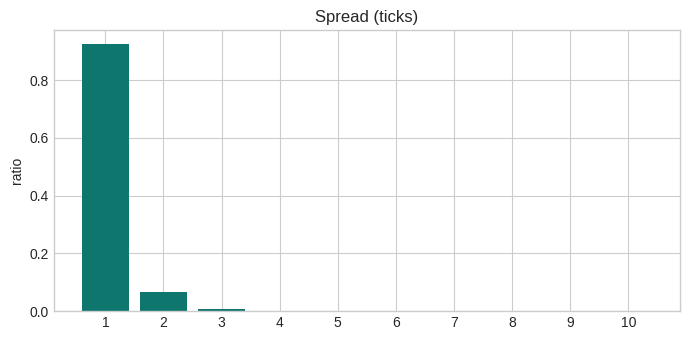

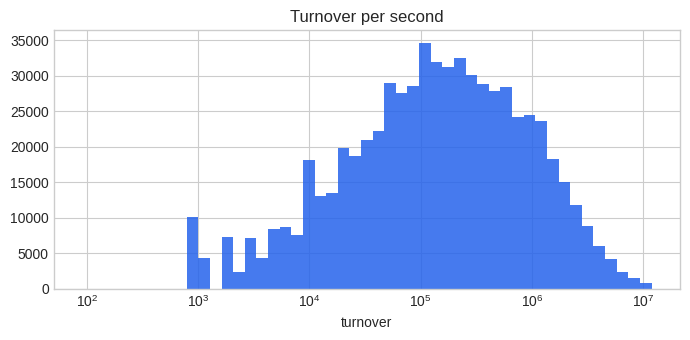

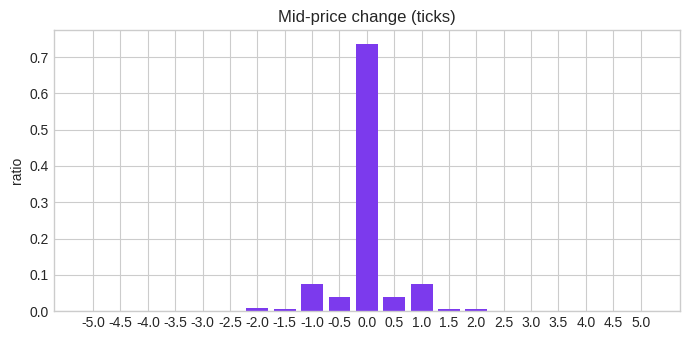

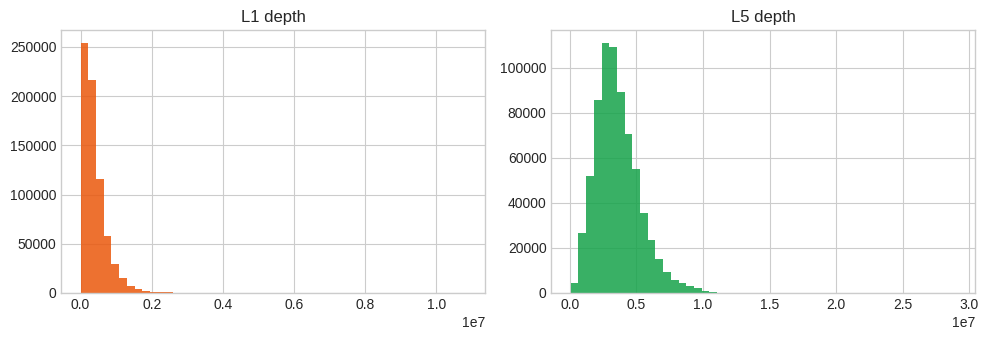

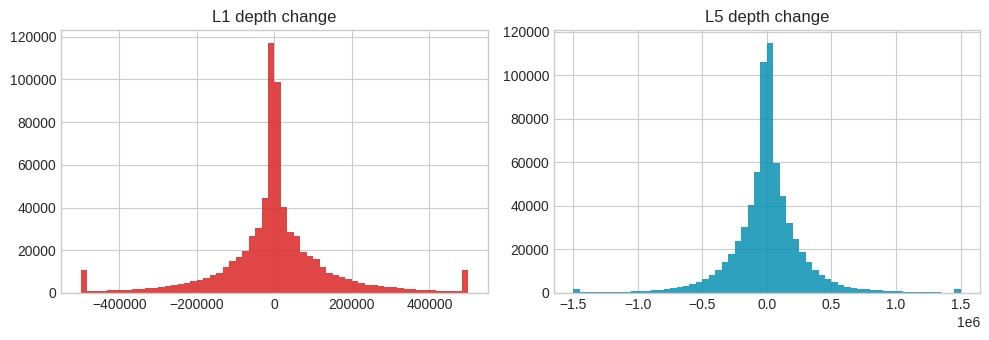

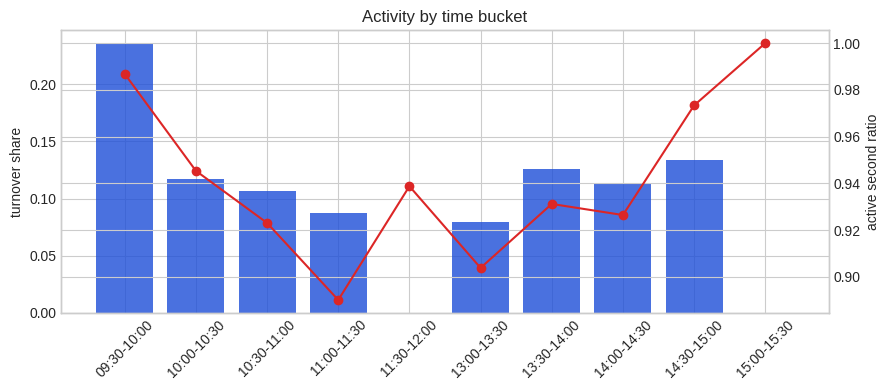

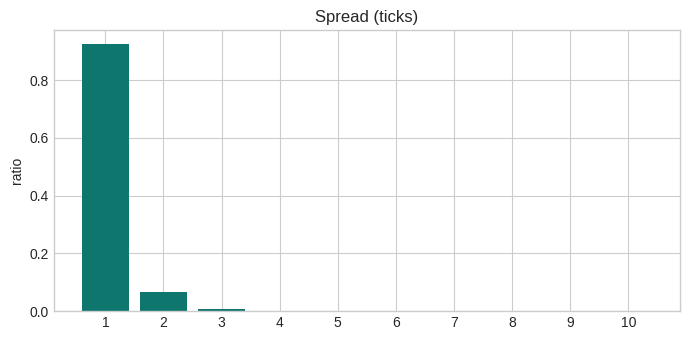

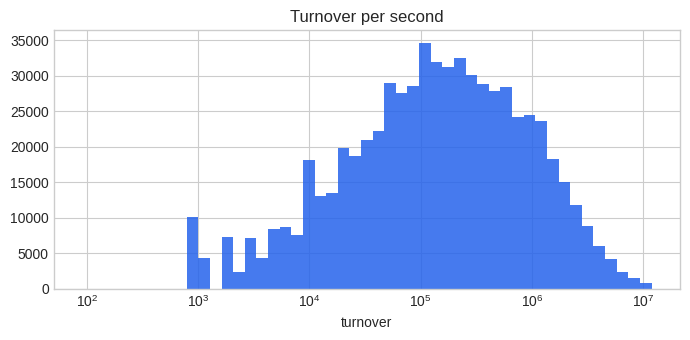

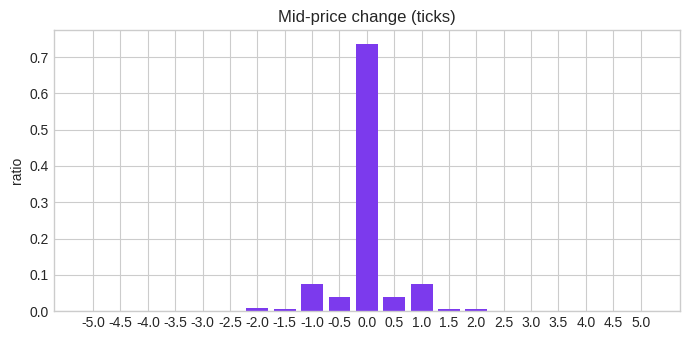

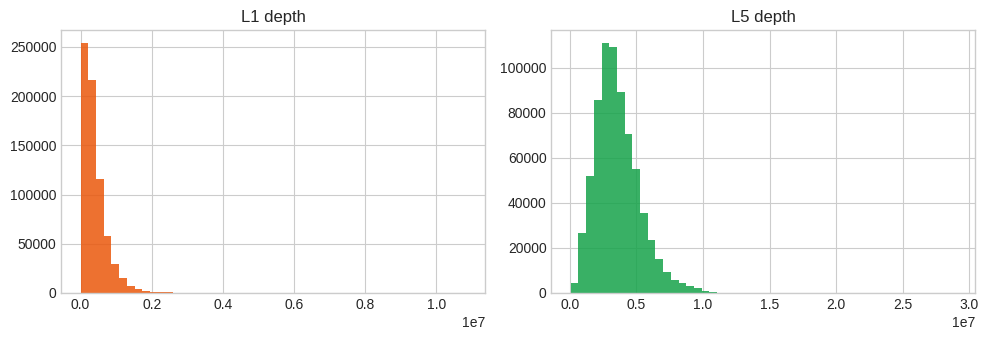

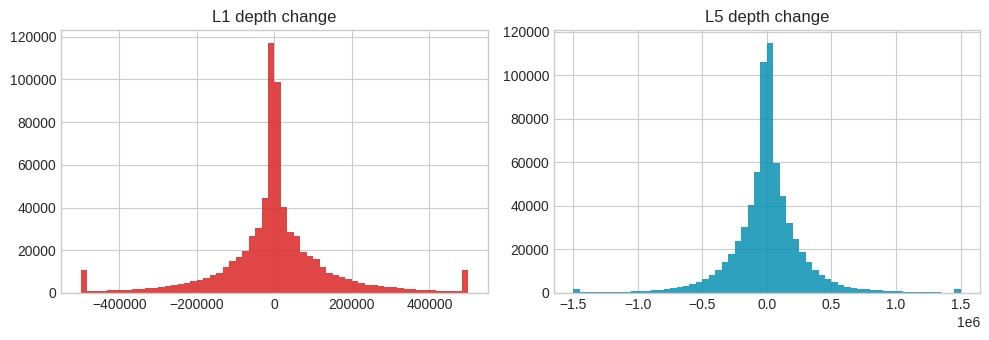

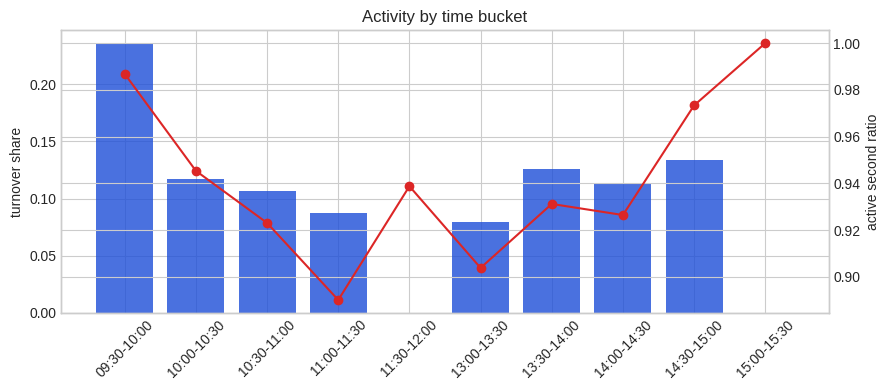

In [4]:
figs = plot_overview(df, tables)
for fig in figs:
    fig.tight_layout()
    display(fig)
